# 05 - Naive Bayes & SVM

Υλοποίηση κλασικών αλγορίθμων ML για κατηγοριοποίηση πωλήσεων σε 3 κλάσεις: **Low / Medium / High**.

**Αλγόριθμοι:**
- Gaussian Naive Bayes (full dataset)
- Bernoulli Naive Bayes (binary features only)
- LinearSVC — Support Vector Machine (200K sample)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.svm import LinearSVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
import time, warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
print('Setup OK')


Setup OK


## 1. Φόρτωση Δεδομένων


In [2]:
train = pd.read_parquet('../data/processed/train.parquet')
val   = pd.read_parquet('../data/processed/val.parquet')
test  = pd.read_parquet('../data/processed/test.parquet')

print(f'Train: {train.shape}  ({train["date"].min().date()} → {train["date"].max().date()})')
print(f'Val:   {val.shape}  ({val["date"].min().date()} → {val["date"].max().date()})')
print(f'Test:  {test.shape}  ({test["date"].min().date()} → {test["date"].max().date()})')
print(f'\nClass distribution (train):')
print(train['sales_class'].value_counts(normalize=True).round(3))


Train: (2160731, 75)  (2013-01-01 → 2016-12-31)
Val:   (223933, 75)  (2017-01-01 → 2017-05-31)
Test:  (112708, 75)  (2017-06-01 → 2017-08-15)

Class distribution (train):
sales_class
Medium    0.337
Low       0.334
High      0.330
Name: proportion, dtype: float64


## 2. Προετοιμασία Features & Target


In [3]:
DROP_COLS = ['id', 'date', 'sales', 'sales_class']
FEATURE_COLS = [c for c in train.columns if c not in DROP_COLS]
print(f'Features: {len(FEATURE_COLS)}')
print(f'Πρώτα 10: {FEATURE_COLS[:10]}')

le = LabelEncoder()
y_train = le.fit_transform(train['sales_class'])
y_val   = le.transform(val['sales_class'])
y_test  = le.transform(test['sales_class'])
print(f'\nEncoded classes: {dict(zip(le.classes_, [0,1,2]))}')

X_train = train[FEATURE_COLS].astype('float32').values
X_val   = val[FEATURE_COLS].astype('float32').values
X_test  = test[FEATURE_COLS].astype('float32').values
print(f'\nX_train: {X_train.shape}')
print(f'X_val:   {X_val.shape}')
print(f'X_test:  {X_test.shape}')


Features: 71
Πρώτα 10: ['store_nbr', 'onpromotion', 'cluster', 'oil_price', 'transactions', 'is_national_holiday', 'is_regional_holiday', 'is_local_holiday', 'is_holiday', 'year']



Encoded classes: {'High': 0, 'Low': 1, 'Medium': 2}

X_train: (2160731, 71)
X_val:   (223933, 71)
X_test:  (112708, 71)


In [4]:
def evaluate_model(name, y_true, y_pred, classes, train_time=None):
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average='macro')
    print(f'\n{"="*55}')
    print(f'  {name}')
    print(f'{"="*55}')
    print(f'  Accuracy: {acc:.4f}')
    print(f'  Macro F1: {f1:.4f}')
    if train_time is not None:
        print(f'  Train time: {train_time:.1f}s')
    print(f'\n{classification_report(y_true, y_pred, target_names=classes)}')
    return acc, f1


## 3. Gaussian Naive Bayes

Ο **GaussianNB** υποθέτει ότι κάθε feature ακολουθεί κανονική κατανομή μέσα σε κάθε κλάση. Πλεονέκτημα: εξαιρετικά γρήγορος και scalable.


In [5]:
print('Training Gaussian Naive Bayes στο full training set...')
t0 = time.time()
gnb = GaussianNB()
gnb.fit(X_train, y_train)
gnb_time = time.time() - t0

y_pred_gnb = gnb.predict(X_val)
gnb_acc, gnb_f1 = evaluate_model('Gaussian Naive Bayes', y_val, y_pred_gnb, le.classes_, gnb_time)


Training Gaussian Naive Bayes στο full training set...



  Gaussian Naive Bayes
  Accuracy: 0.7372
  Macro F1: 0.6780
  Train time: 0.8s

              precision    recall  f1-score   support

        High       0.81      0.96      0.88     88462
         Low       0.44      0.49      0.46     33184
      Medium       0.78      0.63      0.69    102287

    accuracy                           0.74    223933
   macro avg       0.68      0.69      0.68    223933
weighted avg       0.74      0.74      0.73    223933



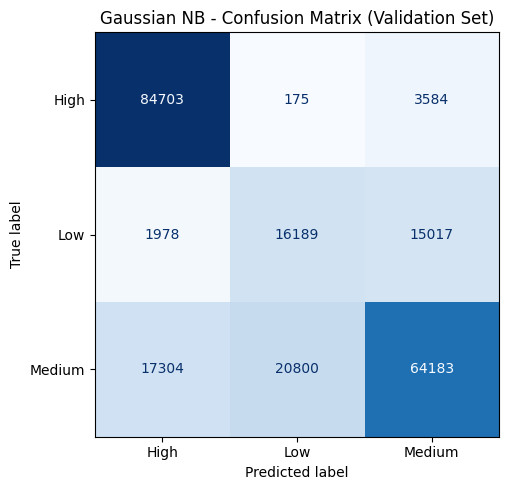

In [6]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_val, y_pred_gnb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Gaussian NB - Confusion Matrix (Validation Set)')
plt.tight_layout()
plt.show()


## 4. Bernoulli Naive Bayes

Ο **BernoulliNB** είναι σχεδιασμένος για binary features. Χρησιμοποιούμε μόνο τα one-hot encoded columns (family, type, state) και τα boolean flags (is_holiday, is_weekend, κλπ.).


In [7]:
binary_cols = [c for c in FEATURE_COLS
               if c.startswith(('family_', 'type_', 'state_', 'is_'))]
print(f'Binary features: {len(binary_cols)}')

X_train_bin = train[binary_cols].astype('float32').values
X_val_bin   = val[binary_cols].astype('float32').values

print('Training Bernoulli Naive Bayes...')
t0 = time.time()
bnb = BernoulliNB()
bnb.fit(X_train_bin, y_train)
bnb_time = time.time() - t0

y_pred_bnb = bnb.predict(X_val_bin)
bnb_acc, bnb_f1 = evaluate_model('Bernoulli NB (binary features)', y_val, y_pred_bnb, le.classes_, bnb_time)


Binary features: 59
Training Bernoulli Naive Bayes...



  Bernoulli NB (binary features)
  Accuracy: 0.6734
  Macro F1: 0.6412
  Train time: 0.7s

              precision    recall  f1-score   support

        High       0.88      0.83      0.86     88462
         Low       0.33      0.67      0.44     33184
      Medium       0.76      0.54      0.63    102287

    accuracy                           0.67    223933
   macro avg       0.66      0.68      0.64    223933
weighted avg       0.74      0.67      0.69    223933



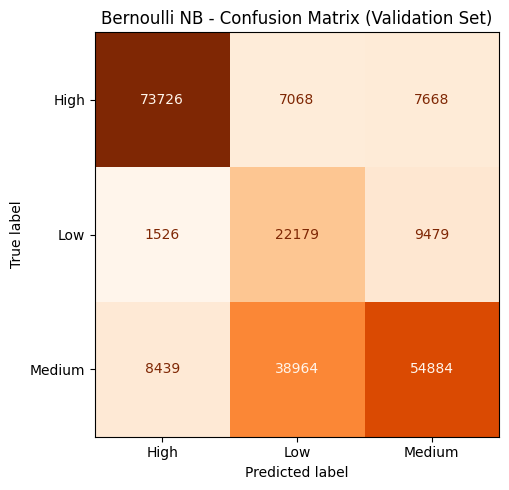

In [8]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_val, y_pred_bnb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, colorbar=False, cmap='Oranges')
ax.set_title('Bernoulli NB - Confusion Matrix (Validation Set)')
plt.tight_layout()
plt.show()


## 5. Support Vector Machine (LinearSVC)

Το **SVM** βρίσκει ένα hyperplane που μεγιστοποιεί το margin μεταξύ κλάσεων. Χρησιμοποιούμε:
- **LinearSVC**: γρηγορότερο από SVC για μεγάλα datasets
- **200,000 τυχαίο sample** για λόγους ταχύτητας (πλήρες dataset δεν είναι scalable)
- **StandardScaler**: τα SVM απαιτούν κανονικοποιημένα features


In [9]:
SAMPLE_SIZE = 200_000
rng = np.random.RandomState(42)
idx = rng.choice(len(X_train), size=SAMPLE_SIZE, replace=False)
X_svm = X_train[idx]
y_svm = y_train[idx]
print(f'SVM training sample: {X_svm.shape}')

scaler = StandardScaler()
X_svm_sc  = scaler.fit_transform(X_svm)
X_val_sc  = scaler.transform(X_val)
X_test_sc = scaler.transform(X_test)

print('Training LinearSVC...')
t0 = time.time()
svm = LinearSVC(C=1.0, max_iter=2000, random_state=42)
svm.fit(X_svm_sc, y_svm)
svm_time = time.time() - t0

y_pred_svm = svm.predict(X_val_sc)
svm_acc, svm_f1 = evaluate_model('LinearSVC (200K sample)', y_val, y_pred_svm, le.classes_, svm_time)


SVM training sample: (200000, 71)
Training LinearSVC...



  LinearSVC (200K sample)
  Accuracy: 0.8131
  Macro F1: 0.7463
  Train time: 32.8s

              precision    recall  f1-score   support

        High       0.89      0.94      0.92     88462
         Low       0.63      0.44      0.52     33184
      Medium       0.79      0.82      0.80    102287

    accuracy                           0.81    223933
   macro avg       0.77      0.74      0.75    223933
weighted avg       0.80      0.81      0.81    223933



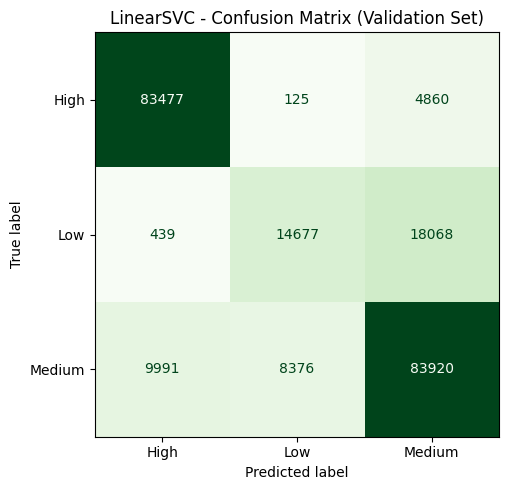

In [10]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_val, y_pred_svm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, colorbar=False, cmap='Greens')
ax.set_title('LinearSVC - Confusion Matrix (Validation Set)')
plt.tight_layout()
plt.show()


## 6. Σύγκριση Μοντέλων


In [11]:
models     = ['Gaussian NB', 'Bernoulli NB', 'LinearSVC']
val_accs   = [gnb_acc, bnb_acc, svm_acc]
val_f1s    = [gnb_f1, bnb_f1, svm_f1]
train_times = [gnb_time, bnb_time, svm_time]

results_df = pd.DataFrame({
    'Model': models,
    'Val Accuracy': val_accs,
    'Val Macro F1': val_f1s,
    'Train Time (s)': train_times
}).sort_values('Val Macro F1', ascending=False)

print(results_df.to_string(index=False))


       Model  Val Accuracy  Val Macro F1  Train Time (s)
   LinearSVC      0.813074      0.746276       32.770158
 Gaussian NB      0.737162      0.678044        0.755671
Bernoulli NB      0.673367      0.641231        0.725247


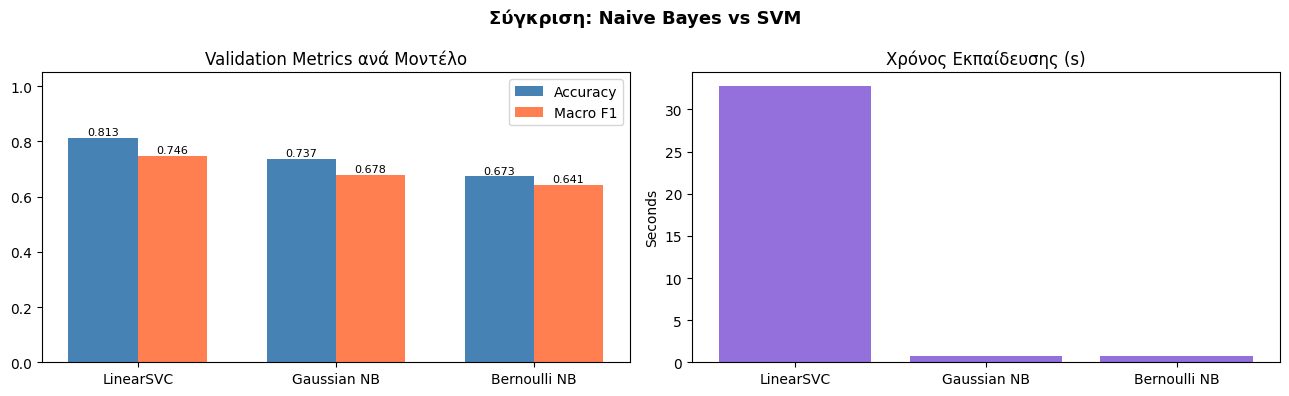

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

x = np.arange(len(results_df))
width = 0.35
axes[0].bar(x - width/2, results_df['Val Accuracy'], width, label='Accuracy', color='steelblue')
axes[0].bar(x + width/2, results_df['Val Macro F1'],  width, label='Macro F1',  color='coral')
axes[0].set_xticks(x)
axes[0].set_xticklabels(results_df['Model'])
axes[0].set_ylim(0, 1.05)
axes[0].set_title('Validation Metrics ανά Μοντέλο')
axes[0].legend()
for i, (a, f) in enumerate(zip(results_df['Val Accuracy'], results_df['Val Macro F1'])):
    axes[0].text(i - width/2, a + 0.01, f'{a:.3f}', ha='center', fontsize=8)
    axes[0].text(i + width/2, f + 0.01, f'{f:.3f}', ha='center', fontsize=8)

axes[1].bar(results_df['Model'], results_df['Train Time (s)'], color='mediumpurple')
axes[1].set_title('Χρόνος Εκπαίδευσης (s)')
axes[1].set_ylabel('Seconds')

plt.suptitle('Σύγκριση: Naive Bayes vs SVM', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 7. Τελική Αξιολόγηση στο Test Set

Αξιολογούμε το **LinearSVC** (καλύτερη F1) στο test set (Ιούν–Αυγ 2017).


In [13]:
y_pred_test = svm.predict(X_test_sc)
test_acc, test_f1 = evaluate_model('LinearSVC — TEST SET', y_test, y_pred_test, le.classes_)

print(f'\n>>> Test Set Summary:')
print(f'    Accuracy : {test_acc:.4f}')
print(f'    Macro F1 : {test_f1:.4f}')



  LinearSVC — TEST SET
  Accuracy: 0.8218
  Macro F1: 0.7319



              precision    recall  f1-score   support

        High       0.89      0.95      0.92     45511
         Low       0.65      0.36      0.46     15062
      Medium       0.79      0.85      0.81     52135

    accuracy                           0.82    112708
   macro avg       0.78      0.72      0.73    112708
weighted avg       0.81      0.82      0.81    112708


>>> Test Set Summary:
    Accuracy : 0.8218
    Macro F1 : 0.7319


## 8. Συμπεράσματα

| Μοντέλο | Πλεονεκτήματα | Μειονεκτήματα |
|---|---|---|
| **Gaussian NB** | Πολύ γρήγορο, scalable | Υπόθεση κανονικής κατανομής, αδύναμο με one-hot |
| **Bernoulli NB** | Ιδανικό για binary features | Αγνοεί αριθμητικά features |
| **LinearSVC** | Καλύτερη ακρίβεια, ισχυρός classifier | Απαιτεί scaling, αργό σε μεγάλα datasets |

**Γενική παρατήρηση:** Το LinearSVC αποδίδει καλύτερα από τους NB αλγορίθμους χάρη στο ότι βρίσκει βέλτιστο hyperplane separation. Παρ' όλα αυτά, η εκπαίδευση γίνεται σε sample λόγω υπολογιστικού κόστους. Τα ensemble μοντέλα (Random Forest, Gradient Boosting) και τα νευρωνικά δίκτυα αναμένεται να αποδώσουν καλύτερα — βλ. notebooks 07 και 08.
